<br>

<div align="center">
<h1>Использование языка программирования Julia для решения математических задач
<br> 
<br> 
Часть II</h1>
</div>

<br>

<br>

<br>

<br>

<br>

<br>


<br>

**<span style="font-size: 1.1em">Авторы:</span>** 

**Чуракова Юлия Романовна**  
*Студентка факультета математики и компьютерных наук*  
*Кубанского Государственного Университета*

**<span style="font-size: 1.1em"></span>** **Алексеев Евгений Ростиславович**  
*Кандидат технических наук, доцент*  
*Доцент кафедры информационных технологий*  
*Кубанского Государственного Университета*


<br>

<br>

<br>

<br>

<br>

<br>

<br>

---


**Полная версия пособия доступна в репозитории:** [https://github.com/JuliaChurakova/Julia](https://github.com/JuliaChurakova/Julia)

---

# Литература
1. Алексеев, Е. Р. Scilab: Решение инженерных и математических задач: учеб. издание. / Е.Р. Алексеев, К. В. Дога, О. В. Чеснокова М. – Базальт СПО; ДМК Пресс, 2024. – 440 с.
2. Балакин, А. А. Численные методы и математическое моделирование: Учебное пособие / А.А. Балакин. – Долгопрудный: Издательский Дом «Интеллект», 2022. – 288 с.
3. Деза, Е. И. Введение в криптографию: Теоретико-числовые основы защиты информации. Учебное пособие / Е. И. Деза, Л. В. Котова. – Москва: ЛЕНАНД, 2022. – 376 с.
4. Кнауб, Л. В. Теоретико-численные методы в криптографии / Л. В. Кнауб, Е. А. Новиков, Ю. А. Шитов; Сибирский федеральный университет – Красноярск: 2011. – 160 с.

# Глава 14 Решение задач обработки эксперимента

## 14.1 Метод наименьших квадратов

**Метод наименьших квадратов (МНК)** – это математический подход, позволяющий найти аналитическую функцию, наилучшим образом приближающую экспериментальные данные. Иными словами, с помощью МНК можно подобрать такую функцию, которая будет максимально близко проходить к заданным точкам.

Предположим, в ходе эксперимента получена некоторая зависимость $y(x)$, представленная в виде таблицы:

| <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> |
|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| $x$ |$x_1$|$x_2$|$x_3$|...|$x_{n-1}$|$x_n$| 
| $y$ |$y_1$|$y_2$|$y_3$|...|$y_{n-1}$|$y_n$| 


Требуется построить аналитическую зависимость $f(x, a_1, a_2, \dots, a_k)$, которая с высокой точностью описывает экспериментальные данные. Построение подобной кривой называют **аппроксимацией** экспериментальных значений.

Суть МНК заключается в том, чтобы подобрать параметры функции $f(x, a_1, a_2, \dots, a_k)$ таким образом, чтобы сумма квадратов отклонений между измеренными значениями $ y_i$ и расчётными $Y_i = f(x_i, a_1, a_2, \dots, a_k)$ была минимальной.

$$
S(a_1, a_2, \dots, a_k) = \sum_{i=1}^n (y_i - (f(x, a_1, a_2, \dots, a_k)))^2 \rightarrow \min
$$

**Этапы решения задачи:**  

1. на основе экспериментальных данных подбирается вид функции  $Y = f(x, a_1, a_2, \dots, a_k)$;

2. подобрать коэффициенты  $a_1, a_2, \dots, a_k$ выбранной зависимости. 

Таким образом, МНК сводится к оптимизационной задаче, где коэффициенты подбираются так, чтобы минимизировать расхождения между моделью и реальными данными.

### 14.1.1 Подбор параметров экспериментальной зависимости методом наименьших квадратов

Для решения задачи подбора параметров методом наименьших квадратов воспользуемся достаточным условием минимума функции.

**Достаточное условие минимума:**
$$
\frac{\partial S}{\partial a_j} = 0, \quad j = 1, 2, \dots, k
$$

Если параметры $a_i$ входят в зависимость $Y = f(x, a_1 , a_2 , …, a_k )$ линейно, то
получим систему из k линейных уравнений с k неизвестными:

$$
\begin{cases}
\sum_{i=1}^n 2[y_i - f(x_i, a_1, a_2, \dots, a_k)] \frac{\partial f}{\partial a_1} = 0 \\
\sum_{i=1}^n 2[y_i - f(x_i, a_1, a_2, \dots, a_k)] \frac{\partial f}{\partial a_2} = 0 \\
\vdots \\
\sum_{i=1}^n 2[y_i - f(x_i, a_1, a_2, \dots, a_k)] \frac{\partial f}{\partial a_k} = 0
\end{cases}
$$


#### 14.1.1.1 Подбор коэффициентов линейной зависимости

Рассмотрим подбор параметров линейной функции вида:

$$
Y = a_1 + a_2x
$$

Функция суммы квадратов отклонений для этого случая принимает вид:

$$
S(a_1, a_2) = \sum_{i=1}^n [y_i - (a_1 + a_2x_i)]^2 \rightarrow \min
$$

Для нахождения минимума приравняем частные производные к нулю:

$$
\begin{cases}
\frac{\partial S}{\partial a_1} = -2\sum_{i=1}^n [y_i - (a_1 + a_2x_i)] = 0 \\
\frac{\partial S}{\partial a_2} = -2\sum_{i=1}^n [y_i - (a_1 + a_2x_i)]x_i = 0
\end{cases} 
$$

После преобразований получаем систему уравнений:

$$
\begin{cases}
na_1 + a_2\sum_{i=1}^n x_i = \sum_{i=1}^n y_i \\
a_1\sum_{i=1}^n x_i + a_2\sum_{i=1}^n x_i^2 = \sum_{i=1}^n x_i y_i
\end{cases}
$$

Решение данной системы дает искомые коэффициенты:

$$
a_1 = \frac{\sum_{i=1}^n y_i - a_2\sum_{i=1}^n x_i}{n} 
$$
$$
a_2 = \frac{n\sum_{i=1}^n x_i y_i - \sum_{i=1}^n x_i \sum_{i=1}^n y_i}{n\sum_{i=1}^n x_i^2 - (\sum_{i=1}^n x_i)^2}
$$

#### 14.1.1.2 Подбор коэффициентов полинома k-й степени

Для полиномиальной зависимости второго порядка:

$$
Y = a_1 + a_2x + a_3x^2
$$

Функция суммы квадратов отклонений:

$$
S(a_1, a_2, a_3) = \sum_{i=1}^n [y_i - (a_1 + a_2x_i + a_3x_i^2)]^2
$$

После дифференцирования S по $a_1 , a_2 и a_3$ получим систему линейных алгебраических уравнений:

$$
\begin{cases}
n a_1 + a_2 \sum_{i=1}^n x_i + a_3 \sum_{i=1}^n x_i^2 = \sum_{i=1}^n y_i \\
a_1 \sum_{i=1}^n x_i + a_2 \sum_{i=1}^n x_i^2 + a_3 \sum_{i=1}^n x_i^3 = \sum_{i=1}^n x_i y_i \\
a_1 \sum_{i=1}^n x_i^2 + a_2 \sum_{i=1}^n x_i^3 + a_3 \sum_{i=1}^n x_i^4 = \sum_{i=1}^n x_i^2 y_i
\end{cases}
$$
Решив систему, найдём значения параметров $a_1 , a_2 и a_3$.
Для полинома третьей степени:

$$
Y = a_1 + a_2x + a_3x^2 + a_4x^3
$$

cистема уравнений имеет следующий вид:

$$
\begin{cases}
n a_1 + a_2 \sum_{i=1}^n x_i + a_3 \sum_{i=1}^n x_i^2 + a_4 \sum_{i=1}^n x_i^3 = \sum_{i=1}^n y_i \\
a_1 \sum_{i=1}^n x_i + a_2 \sum_{i=1}^n x_i^2 + a_3 \sum_{i=1}^n x_i^3 + a_4 \sum_{i=1}^n x_i^4 = \sum_{i=1}^n x_i y_i \\
a_1 \sum_{i=1}^n x_i^2 + a_2 \sum_{i=1}^n x_i^3 + a_3 \sum_{i=1}^n x_i^4 + a_4 \sum_{i=1}^n x_i^5 = \sum_{i=1}^n x_i^2 y_i \\
a_1 \sum_{i=1}^n x_i^3 + a_2 \sum_{i=1}^n x_i^4 + a_3 \sum_{i=1}^n x_i^5 + a_4 \sum_{i=1}^n x_i^6 = \sum_{i=1}^n x_i^3 y_i
\end{cases}
$$

Для полинома k-й степени вида:

$$
Y = a_1 + a_2x + a_3x^2 + \cdots + a_{k+1}x^k
$$

cистема уравнений имеет следующий вид:

$$
\begin{cases}
a_1 n + a_2 \sum_{i=1}^n x_i + a_3 \sum_{i=1}^n x_i^2 + \cdots + a_{k+1} \sum_{i=1}^n x_i^k = \sum_{i=1}^n y_i \\
a_1 \sum_{i=1}^n x_i + a_2 \sum_{i=1}^n x_i^2 + a_3 \sum_{i=1}^n x_i^3 + \cdots + a_{k+1} \sum_{i=1}^n x_i^{k+1} = \sum_{i=1}^n x_i y_i \\
a_1 \sum_{i=1}^n x_i^2 + a_2 \sum_{i=1}^n x_i^3 + a_3 \sum_{i=1}^n x_i^4 + \cdots + a_{k+1} \sum_{i=1}^n x_i^{k+2} = \sum_{i=1}^n x_i^2 y_i \\
\vdots \\
a_1 \sum_{i=1}^n x_i^k + a_2 \sum_{i=1}^n x_i^{k+1} + a_3 \sum_{i=1}^n x_i^{k+2} + \cdots + a_{k+1} \sum_{i=1}^n x_i^{2k} = \sum_{i=1}^n x_i^k y_i
\end{cases}
$$

В матричной форме:

$$
\begin{pmatrix}
n & \sum_{i=1}^n x_i & \sum_{i=1}^n x_i^2 & \cdots & \sum_{i=1}^n x_i^k \\
\sum_{i=1}^n x_i & \sum_{i=1}^n x_i^2 & \sum_{i=1}^n x_i^3 & \cdots & \sum_{i=1}^n x_i^{k+1} \\
\sum_{i=1}^n x_i^2 & \sum_{i=1}^n x_i^3 & \sum_{i=1}^n x_i^4 & \cdots & \sum_{i=1}^n x_i^{k+2} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\sum_{i=1}^n x_i^k & \sum_{i=1}^n x_i^{k+1} & \sum_{i=1}^n x_i^{k+2} & \cdots & \sum_{i=1}^n x_i^{2k}
\end{pmatrix}
\begin{pmatrix}
a_1 \\
a_2 \\
a_3 \\
\vdots \\
a_{k+1}
\end{pmatrix}
=
\begin{pmatrix}
\sum_{i=1}^n y_i \\
\sum_{i=1}^n x_i y_i \\
\sum_{i=1}^n x_i^2 y_i \\
\vdots \\
\sum_{i=1}^n x_i^k y_i
\end{pmatrix}
$$

Тогда систему уравнений можно записать в виде:

$$
\mathbf{C}\mathbf{a} = \mathbf{g}
$$

где элементы матрицы $\mathbf{C}$ и вектора $\mathbf{g}$ рассчитываются по формулам:

$$
c_{ij} = \sum_{k=1}^n x_k^{i+j-2}, \quad g_i = \sum_{k=1}^n x_k^{i-1} y_k, \quad i, j = 1,2,...,k+1
$$

#### 14.1.1.3 Подбор коэффициентов для функции $Y = ax^b e^{cx}$

После логарифмирования:

$$
\ln Y = \ln a + b \ln x + cx
$$

С заменой $Y_1 = \ln Y$, $A = \ln a$ получаем линейную форму:

$$
Y_1 = A + b \ln x + cx
$$

После дифференцирования получим систему трёх линейных алгебраических уравнений для определения коэффициентов A, b, c:

$$
\begin{cases}
n A + b \sum_{i=1}^n \ln x_i + c \sum_{i=1}^n x_i = \sum_{i=1}^n \ln y_i \\
A \sum_{i=1}^n \ln x_i + b \sum_{i=1}^n (\ln x_i)^2 + c \sum_{i=1}^n x_i \ln x_i = \sum_{i=1}^n \ln y_i \ln x_i \\
A \sum_{i=1}^n x_i + b \sum_{i=1}^n x_i \ln x_i + c \sum_{i=1}^n x_i^2 = \sum_{i=1}^n x_i \ln y_i
\end{cases}
$$

После решения системы коэффициент $a$ находится как $a = e^A$.

#### 14.1.1.4 Функции, приводимые к линейной

1. Для степенной функции $Y = ax^b$:
   $$
   \ln Y = \ln a + b \ln x
   $$
   Замена: $Z = \ln Y$, $X = \ln x$, $A = \ln a$ → $Z = bX + A$

2. Для экспоненциальной функции $Y = ae^{bx}$:
   $$
   \ln Y = \ln a + bx
   $$
   Замена: $Z = \ln Y$, $A = \ln a$ → $Z = bx + A$

3. $Y = \frac{1}{ax+b}$:


   Замена: $Z = \frac{1}{Y}$ → $Z = ax + b$
5. $Y = \frac{x}{ax+b}$:


   Замена: $Z = \frac{1}{Y}$, $X = \frac{1}{x}$ → $Z = a + bX$
7. $Y = a + be^{-x}$:


   Замена: $Z = Y$, $X = e^{-x}$ → $Z = aX + b$

Аналогичными преобразованиями многие зависимости можно свести к решению системы линейных уравнений, что значительно упрощает вычисления.

### 14.1.2 Точность подбора параметров

После определения параметров модели $f(x, a_1, a_2, ..., a_k)$ необходимо оценить качество соответствия модели экспериментальным данным. Основные показатели точности:

**Суммарная квадратичная ошибка:**
$$
S = \sum_{i=1}^n (y_i - f(x_i, a_1, a_2, ..., a_k))^2
$$
Чем ближе S к нулю, тем точнее модель описывает данные.

**Средняя квадратичная ошибка:**
$$
S_t = \sqrt{\frac{S}{n}}
$$
Показывает среднее отклонение модели от экспериментальных значений.

**Относительная ошибка:**
$$
S_{to} = \frac{{S_t}}{M_y} = \frac{{\frac{\sqrt {\sum_{i=1}^n (y_i - f(x_i, a_1, a_2, ..., a_k))^2}}{n}}}{\frac{\sum_{i=1}^n (y_i)}{n}}
$$
Позволяет оценить точность независимо от масштаба данных.

Относительную ошибку можно перевести в проценты, умножив на 100. Для инженерных расчетов хорошо, если ошибка составляет 5-10%. Если погрешность меньше 2% – это отличный результат для расчётов. Но здесь важно проверить: насколько точными были сами измерения и оборудование.

### 14.1.2 Линия регрессии и коэффициент корреляции

Линия, описываемая уравнением вида $y = a_1 + a_2x$, называется линией регрессии y на x, параметры $a_1$ и $a_2$ называются коэффициентами регрессии и определяются формулами:

$$
a_1 = \frac{\sum_{i=1}^n y_i - a_2\sum_{i=1}^n x_i}{n} 
$$
$$
a_2 = \frac{n\sum_{i=1}^n x_i y_i - \sum_{i=1}^n x_i \sum_{i=1}^n y_i}{n\sum_{i=1}^n x_i^2 - (\sum_{i=1}^n x_i)^2}
$$


Для количественной оценки силы линейной зависимости используют **коэффициент корреляции**:
$$
r = \frac{\sum_{i=1}^n (x_i - M_x)(y_i - M_y)}{\sqrt{\sum (x_i - M_x)^2 \sum (y_i - M_y)^2}}
$$
где $M_x = \frac{\sum_{i=1}^n x_i}{n}$ - среднее значение x, $M_y = \frac{\sum_{i=1}^n y_i}{n}$ - среднее значение y. 

**Характеристики коэффициента:**

- диапазон значений: от -1 до 1;
- |r| ≈ 1 – сильная линейная связь;
- r ≈ 0 – отсутствие линейной связи.

Для того чтобы проверить, значимо ли отличается от нуля коэффициент корреляции, можно использовать критерий Стьюдента. Вычисленное значение критерия определяется по формуле:
$$
t = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}}
$$
Рассчитанное по формуле значение t сравнивается со значением, взятым из таблицы распределения Стьюдента:

| k \ p  | 0.99   | 0.98   | 0.95   | 0.90  | 0.80  | 0.70  | 0.60  |
|---------|--------|--------|--------|-------|-------|-------|-------|
| 1       | 63.657 | 31.821 | 12.706 | 6.314 | 3.078 | 1.963 | 1.376 |
| 2       | 9.925  | 6.965  | 4.303  | 2.920 | 1.886 | 1.386 | 1.061 |
| 3       | 5.841  | 4.541  | 3.182  | 2.353 | 1.638 | 1.250 | 0.978 |
| 4       | 4.604  | 3.747  | 2.776  | 2.132 | 1.533 | 1.190 | 0.941 |
| 5       | 4.032  | 3.365  | 2.571  | 2.050 | 1.476 | 1.156 | 0.920 |
| 6       | 3.707  | 3.141  | 2.447  | 1.943 | 1.440 | 1.134 | 0.906 |
| 7       | 3.499  | 2.998  | 2.365  | 1.895 | 1.415 | 1.119 | 0.896 |
| 8       | 3.355  | 2.896  | 2.306  | 1.860 | 1.387 | 1.108 | 0.889 |
| 9       | 3.250  | 2.821  | 2.261  | 1.833 | 1.383 | 1.100 | 0.883 |
| 10      | 3.169  | 2.764  | 2.228  | 1.812 | 1.372 | 1.093 | 0.879 |
| 11      | 3.106  | 2.718  | 2.201  | 1.796 | 1.363 | 1.088 | 0.876 |
| 12      | 3.055  | 2.681  | 2.179  | 1.782 | 1.356 | 1.083 | 0.873 |
| 13      | 3.012  | 2.650  | 2.160  | 1.771 | 1.350 | 1.079 | 0.870 |
| 14      | 2.977  | 2.624  | 2.145  | 1.761 | 1.345 | 1.076 | 0.868 |
| 15      | 2.947  | 2.602  | 2.131  | 1.753 | 1.341 | 1.074 | 0.866 |
| 16      | 2.921  | 2.583  | 2.120  | 1.746 | 1.337 | 1.071 | 0.865 |
| 17      | 2.898  | 2.567  | 2.110  | 1.740 | 1.333 | 1.069 | 0.863 |
| 18      | 2.878  | 2.552  | 2.101  | 1.734 | 1.330 | 1.067 | 0.862 |
| 19      | 2.861  | 2.539  | 2.093  | 1.729 | 1.328 | 1.066 | 0.861 |
| 20      | 2.845  | 2.528  | 2.086  | 1.725 | 1.325 | 1.064 | 0.860 |
| 21      | 2.831  | 2.518  | 2.080  | 1.721 | 1.323 | 1.063 | 0.859 |
| 22      | 2.819  | 2.508  | 2.074  | 1.717 | 1.321 | 1.061 | 0.858 |
| 23      | 2.807  | 2.500  | 2.069  | 1.714 | 1.319 | 1.060 | 0.858 |
| 24      | 2.797  | 2.492  | 2.064  | 1.711 | 1.318 | 1.059 | 0.857 |
| 25      | 2.779  | 2.485  | 2.060  | 1.708 | 1.316 | 1.058 | 0.856 |
| 26      | 2.771  | 2.479  | 2.056  | 1.706 | 1.315 | 1.058 | 0.856 |
| 27      | 2.763  | 2.473  | 2.052  | 1.703 | 1.314 | 1.057 | 0.855 |
| 28      | 2.756  | 2.467  | 2.048  | 1.701 | 1.313 | 1.056 | 0.855 |
| 29      | 2.750  | 2.462  | 2.045  | 1.699 | 1.311 | 1.055 | 0.854 |
| 30      | 2.704  | 2.457  | 2.042  | 1.697 | 1.310 | 1.055 | 0.854 |
| 40      | 2.660  | 2.423  | 2.021  | 1.684 | 1.303 | 1.050 | 0.851 |
| 60      | 2.612  | 2.390  | 2.000  | 1.671 | 1.296 | 1.046 | 0.848 |
| 120     | 2.617  | 2.358  | 1.980  | 1.658 | 1.289 | 1.041 | 0.845 |
| ∞       | 2.576  | 2.326  | 1.960  | 1.645 | 1.282 | 1.036 | 0.842 |


- p – уровнь значимости (стандартное значение p = 0.95);
- k – cтепень свободы (k = n - 2).

Если полученная по формуле величина t больше табличного значения, то коэффициент корреляции значимо отличен от нуля.

### 14.1.3 Нелинейная корреляция

Когда связь имеет нелинейный характер (квадратичная, экспоненциальная, логарифмическая и др.), используют **индекс корреляции** $R$. Этот показатель рассчитывается по формуле:
$$
R = \sqrt{1 - \frac{\sum_{i=1}^n (y_i - Y_i)^2}{\sum_{i=1}^n (y_i - M_y)^2}}
$$
где 0 ≤ R ≤ 1. Характеризует тесноту связи для любых зависимостей.

**Характеристики коэффициента:**
- R ≈ 1 – сильная зависимость;
- R ≈ 0 – отсутствие связи;
- Для линейных моделей |r| = R.

### 14.1.4 Решение задач в Julia 

**Задача 1.** В «Основах химии» Д.И. Менделеева приводятся данные о растворимости $Na NO_3$  (P) в зависимости от температуры воды. В 100 частях воды растворяется следующее число условных частей  при соответствующих температурах.

| <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> |
|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| $T, ^oC$ | 0| 4| 10| 15|21| 29 | 36| 51|58|
| P | 66.7| 71| 76.3| 80.6|85.7| 92.9 | 99.4 | 113.6|125.1|

Температура 32°С не входит в наблюдаемые значения. Необходимо определить, какова будет растворимость $NaNO_3$   при соответствующих температурах. 


Свободный член (a): 67.5078
Коэффициент наклона (b): 0.8706

Суммарная квадратичная ошибка: 6.44
Средняя квадратичная ошибка: 0.846
Относительная ошибка: 0.94%

Коэффициент корреляции (r): 0.999

Критерий Стьюдента: 57.826

Прогноз при температуре 32°C: 95.36828680897646



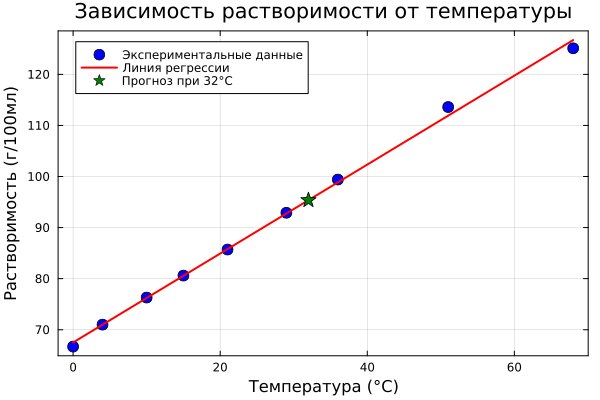

In [1]:
using Plots

# Исходные данные
t = [0, 4, 10, 15, 21, 29, 36, 51, 68]
s = [66.7, 71, 76.3, 80.6, 85.7, 92.9, 99.4, 113.6, 125.1]
n = length(t)
t_avg = sum(t) / n
s_avg = sum(s) / n

# Коэффициенты линейной регрессии 
sum_t = sum(t)
sum_s = sum(s)
sum_ts = sum(t .* s)
sum_t2 = sum(t.^2)
b = (n * sum_ts - sum_t * sum_s) / (n * sum_t2 - sum_t^2)
a = s_avg - b * t_avg

println("Свободный член (a): ", round(a, digits=4))
println("Коэффициент наклона (b): ", round(b, digits=4))
println()

# Расчёт ошибок
s_pred = a .+ b .* t
total_err = sum((s .- s_pred).^2)
mean_err = sqrt(total_err / n)
rel_err = mean_err / s_avg

println("Суммарная квадратичная ошибка: ", round(total_err, digits=2))
println("Средняя квадратичная ошибка: ", round(mean_err, digits=3))
println("Относительная ошибка: ", round(rel_err * 100, digits=2), "%")
println()

# Коэффициент корреляции 
r = sum((t .- t_avg) .* (s .- s_avg)) / sqrt(sum((t .- t_avg).^2) * sum((s .- s_avg).^2))

println("Коэффициент корреляции (r): ", round(r, digits=4))
println()

# Критерий Стьюдента
t_val = r * sqrt(n - 2) / sqrt(1 - r^2)
println("Критерий Стьюдента: ", round(t_val, digits=3))
println()

# Прогноз
new_t = 32
pred_s = a + b * new_t
println("Прогноз при температуре ", new_t, "°C: ", pred_s)
println()

# График
plot(t, s, seriestype = :scatter, color = :blue, markersize = 6,
     label = "Экспериментальные данные",
     title = "Зависимость растворимости от температуры",
     xlabel = "Температура (°C)", ylabel = "Растворимость (г/100мл)",
     legend = :topleft, grid = true, framestyle = :box)

plot!(minimum(t):maximum(t), x -> a + b * x, color = :red, linewidth = 2, label = "Линия регрессии")
scatter!([new_t], [pred_s], color = :green, markersize = 8, marker = :star, label = "Прогноз при $(new_t)°C")


**Задача 2.** Производится наблюдение над двумя переменными – процентным содержанием протеина (P) и крахмала (K) в зернах пшеницы. Обе переменные характеризуют качество пшеницы, но определение протеина требует сложного химического анализа, а определение крахмала может быть сделано гораздо проще. В таблице приведены результаты 20 наблюдений. Необходимо произвести выравнивание этих наблюдений по квадратичной и по кубической параболам, а затем сравнить результаты полученных вычислений.

| <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> |
|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| P,% |10.3| 12.2|14.5| 11.1 |10.9| 18.1 |14 | 10.8 |11.4|11 | 10.2|17| 13.8 |10.1| 14.4 |15.8 | 15.6 |15|13.3 |19|
| K,% | 6 |75| 87| 55|34| 98| 91| 45 |51| 17 |36| 97| 74|24| 85| 96| 92 |94| 84 |99|

Напишем небольшой код, который позволяет построить график экспериментальных точек.


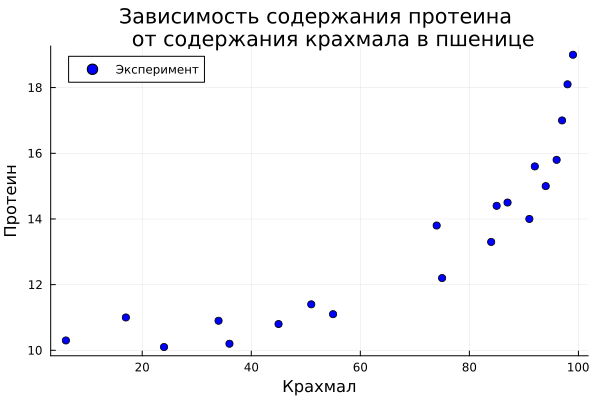

In [2]:
using Plots

P = [10.3, 12.2, 14.5, 11.1, 10.9, 18.1, 14.0, 10.8, 11.4, 11, 10.2, 17, 13.8, 10.1, 14.4, 15.8, 15.6, 15, 13.3, 19]
K = [6, 75, 87, 55, 34, 98, 91, 45, 51, 17, 36, 97, 74, 24, 85, 96, 92, 94, 84, 99]
scatter(K, P, label="Эксперимент", color = :blue, title = "Зависимость содержания протеина 
    от содержания крахмала в пшенице")
xlabel!("Крахмал")
ylabel!("Протеин")


При попытке соединить точки график ломается.

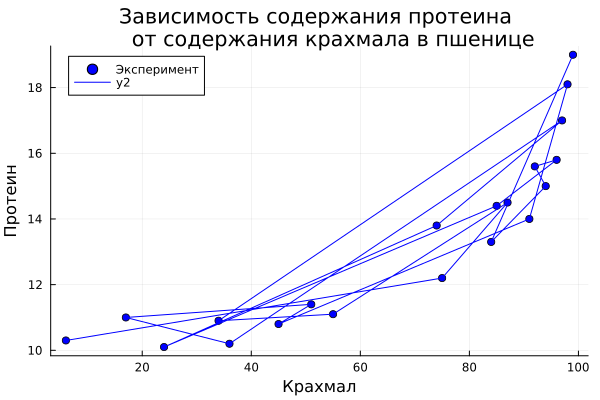

In [3]:
using Plots

P = [10.3, 12.2, 14.5, 11.1, 10.9, 18.1, 14.0, 10.8, 11.4, 11, 10.2, 17, 13.8, 10.1, 14.4, 15.8, 15.6, 15, 13.3, 19]
K = [6, 75, 87, 55, 34, 98, 91, 45, 51, 17, 36, 97, 74, 24, 85, 96, 92, 94, 84, 99]
scatter(K, P, label="Эксперимент", color = :blue, title = "Зависимость содержания протеина 
    от содержания крахмала в пшенице")
plot!(K, P, color = :blue)
xlabel!("Крахмал")
ylabel!("Протеин")

Это связано с тем, что массивы P и K не упорядочены по возрастанию значений K. Это может мешать и в других моментах решения задачи, поэтому необходимо упорядочить массивы P и K по возрастанию элементов массива K. В Julia есть функции сортировки, но так как нужна сортировка двух массивов по возрастанию элементов одного из них, напишем это самостоятельно, воспользовавшись алгоритмом «пузырька».
Код всей программы решения задачи и результаты её работы приведены ниже.


Коэффициенты полинома 2-й степени:
a0 = 11.5595058189
a1 = -0.0879414289
a2 = 0.0014423833

Коэффициенты полинома 3-й степени:
b0 = 9.7214626329
b1 = 0.0899538482
b2 = -0.0025791578
b3 = 2.4944e-5

Ошибки аппроксимации:
Для полинома 2-й степени: 14.0911209865
Для полинома 3-й степени: 10.3538143973


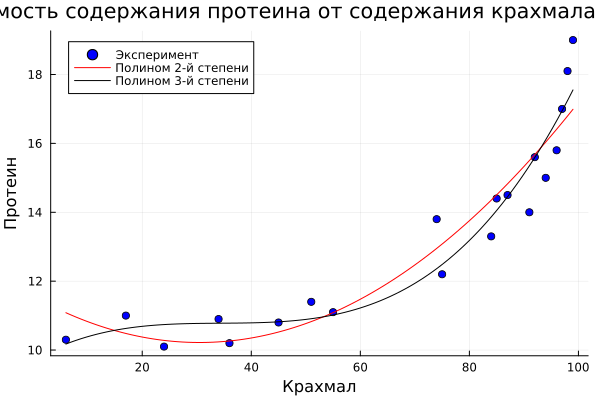

In [4]:
using Plots

P = [10.3, 12.2, 14.5, 11.1, 10.9, 18.1, 14.0, 10.8, 11.4, 11, 10.2, 17, 13.8, 10.1, 14.4, 15.8, 15.6, 15, 13.3, 19]
K = [6, 75, 87, 55, 34, 98, 91, 45, 51, 17, 36, 97, 74, 24, 85, 96, 92, 94, 84, 99]
n = length(K)

# Средние значения
Mk = sum(K) / n
Mp = sum(P) / n

# Сортировка по K
perm = sortperm(K) #возвращает перестановку индексов, которая бы отсортировала массив K по возрастанию
K = K[perm]
P = P[perm]

# Функция для вычисления коэффициентов полиномиальной регрессии степени k
function polyfit(K, P, k)
    C = [sum(K .^ (i + j)) for i in 0:k, j in 0:k]
    d = [sum(P .* K .^ i) for i in 0:k]
    return C \ d
end

a = polyfit(K, P, 2)  # полином 2-й степени
b = polyfit(K, P, 3)  # полином 3-й степени

println("\nКоэффициенты полинома 2-й степени:")
println("a0 = ", round(a[1], digits=10))
println("a1 = ", round(a[2], digits=10))
println("a2 = ", round(a[3], digits=10))

println("\nКоэффициенты полинома 3-й степени:")
println("b0 = ", round(b[1], digits=10))
println("b1 = ", round(b[2], digits=10))
println("b2 = ", round(b[3], digits=10))
println("b3 = ", round(b[4], digits=10))

# Создаем точки для графика
t = LinRange(K[1], K[end], 101)
P2 = a[1] .+ a[2] .* t .+ a[3] .* t.^2
P3 = b[1] .+ b[2] .* t .+ b[3] .* t.^2 .+ b[4] .* t.^3

# Ошибки аппроксимации
S2 = sum((P .- (a[1] .+ a[2] .* K .+ a[3] .* K.^2)).^2)
S3 = sum((P .- (b[1] .+ b[2] .* K .+ b[3] .* K.^2 .+ b[4] .* K.^3)).^2)

println("\nОшибки аппроксимации:")
println("Для полинома 2-й степени: ", round(S2, digits=10))
println("Для полинома 3-й степени: ", round(S3, digits=10))

scatter(K, P, label="Эксперимент", color=:blue)
plot!(t, P2, color=:red, label="Полином 2-й степени")
plot!(t, P3, color=:black, label="Полином 3-й степени")
title!("Зависимость содержания протеина от содержания крахмала в пшенице")
xlabel!("Крахмал")
ylabel!("Протеин")


## 14.2 Интерполяция функций

В отличие от аппроксимации, где строится приближенная зависимость, **интерполяция** требует построения функции, точно проходящей через заданные экспериментальные точки. 

Пусть на отрезке [a, b] заданы:
- узлы интерполяции: $a = x_1 < x_2 < ... < x_{n+1} = b$;
- значения неизвестной функции: $y_1 = f(x_1), y_2 = f(x_2), ..., y_{n+1} = f(x_{n+1})$.

Требуется построить интерполирующую функцию F(x), которая в узлах интерполяции принимает те же значения, что и f(x):

$$
F(x_i) = y_i \quad \text{для всех} \quad i = 1,2,...,n+1
$$

Полученную интерполяционную формулу y = F(x) зачастую используют для нахождения приближённых значений данной функции f(x) в точках x, отличных от узлов интерполирования. Такая операция называется интерполированием функции f(x).

### 14.2.1 Канонический полином

Интерполирующая функция в виде полинома n-й степени:
$$
F(x) = a_1 + a_2x + a_3x^2 + \cdots + a_{n+1}x^n
$$

Коэффициенты находятся из системы:
$$
\begin{cases}
a_1 + a_2x_1 + \cdots + a_{n+1}x_1^n = y_1 \\
a_1 + a_2x_2 + \cdots + a_{n+1}x_2^n = y_2 \\
\vdots \\
a_1 + a_2x_{n+1} + \cdots + a_{n+1}x_{n+1}^n = y_{n+1}
\end{cases}
$$

Решив эту систему линейных алгебраических уравнений, найдём коэффициенты интерполяционного полинома $a_1, a_1, \cdots, a_{n+1}$.

### 14.2.2 Полином Ньютона

Полином Ньютона n-й степени записывается в следующей форме:
$$
F(t) = A_1 + A_2(t-x_1) + A_3(t-x_1)(t-x_2) + \cdots + A_{n+1}(t-x_1)\cdots(t-x_n)
$$

Из условия интерполяции в точке $x_1$:
$$
F(x_1) = A_1 = y_1
$$

Используя условие для точки $x_2$:
$$
F(x_2) = A_1 + A_2(x_2-x_1) = y_2
$$

Выражаем $A_2$:
$$
A_2 = \frac{y_2 - y_1}{x_2 - x_1} = y_{12}
$$

$y_{12}$ – разделённая разность первого порядка. По аналогии вводятся и другие разделённые разности первого порядка:
$$
A_3 = \frac{y_3 - y_1}{x_3 - x_1} = y_{13},\quad \cdots \quad, \quad A_{n+1} = \frac{y_{n+1} - y_1}{x_{n+1} - x_1} = y_{1n+1}
$$

Используя условие для точки $x_3$:
$$
F(x_3) = A_1 + A_2(x_3-x_1) + A_3(x_3-x_1)(x_3-x_2) = y_3
$$

Подставляя уже известные A₁ и A₂:
$$
y_1 + y_{12}(x_3-x_1) + A_3(x_3-x_1)(x_3-x_2) = y_3
$$

Решаем относительно $A_3$:
$$
A_3 = \frac{y_3 - y_1 - y_{12}(x_3-x_1)}{(x_3-x_1)(x_3-x_2)} = \frac{y_{13} - y_{12}}{x_3 - x_2} = y_{123}
$$
$y_{123}$ – разделённая разность второго порядка

Аналогично:
$$
A_4 = \frac{y_{14} - y_{12}}{x_4 - x_2} = y_{124},\quad
A_5 = \frac{y_{15} - y_{12}}{x_5 - x_2} = y_{125}, \quad \cdots \quad, \quad
A_{n+1} = \frac{y_{1n+1} - y_{12}}{x_{n+1} - x_2} = y_{12n+1}
$$

Решаем относительно $A_4$:
$$
A_4 = \frac{y_{124} - y_{123}}{x_4 - x_3} = y_{1234}
$$

Аналогично:
$$
A_5 = \frac{y_{125} - y_{123}}{x_5 - x_3} = y_{1235}, \quad \cdots \quad, \quad
A_{n+1} = \frac{y_{12n+1} - y_{123}}{x_{n+1} - x_3} = y_{123n+1}
$$

Будем продолжать до тех пор, пока не вычислим:
$$
A_n = y_{123...n+1} = \frac{y_{123...n+1} - y_{123...n}}{x{n+1} - x_{n}}
$$

### 14.2.3 Полином Лагранжа
Полином Лагранжа n-й степени записывается в следующей форме:

$$
F(t) = \sum_{i=1}^{n+1} y_i \prod_{\substack{j=1 \\ j \neq i}}^{n+1} \frac{t-x_j}{x_i-x_j}
$$

### 14.2.4 Интерполяция кубическими сплайнами  
 
Исторически сплайны возникли из задачи моделирования гибкой линейки, закреплённой в заданных точках. Форма такой линейки в промежутках между узлами описывается уравнением:  
$$
\varphi^{IV}(x) = 0,  
$$  
решением которого является кубический полином. Это объясняет выбор именно кубических функций для интерполяции – они обеспечивают минимальную кривизну.  
 
Пусть на интервале $[a, b]$ заданы узлы $a = x_1 < x_2 < \dots < x_n = b$ и значения $y_i = y(x_i)$.Кубическим сплайном, интерполирующим на отрезке [a , b] данную функцию y(x), называется функция:  
$$
g_k(s) = a_k + b_k (s - x_k) + c_k (s - x_k)^2 + d_k (s - x_k)^3, \quad s \in [x_{k-1}, x_k], \quad k = 2, \dots, n.  
$$  
Эта функция должна удовлетворять следующим условиям:  
1. **интерполяция в узлах**: $g_k(x_k) = y_k$ и $g_k(x_{k-1}) = y_{k-1}$;  
2. **непрерывность производных**: функция $g(x)$ дважды непрерывно дифференцируема на интервале [a, b];
3. **граничные условия**: вторая производная на концах интервала равна нулю ($g''(a) = g''(b) = 0$).  

Для определения коэффициентов сплайна $a_k$, $b_k$, $c_k$, $d_k$ ($k = 2, 3, \dots, n$) требуется решить систему уравнений.

**Условия интерполяции в узлах:**
$$
g_2(x_1) = y_1, \quad g_k(x_k) = y_k \quad (k = 2, \dots, n)
$$

**Условия гладкости:**
$$
\begin{aligned}
g_{k-1}(x_{k-1}) &= g_k(x_{k}) \\
g'_{k-1}(x_{k-1}) &= g'_k(x_{k}) \quad (k = 2, \dots, n)\\
g''_{k-1}(x_{k-1}) &= g''_k(x_{k})
\end{aligned}
$$

**Граничные условия:**
$$
g''_1(x_0) = 0, \quad g''_n(x_n) = 0
$$

Производные сплайна вычисляются по формулам:
$$
\begin{aligned}
g'_k(s) &= b_k + 2c_k(s-x_k) + 3d_k(s-x_k)^2 \\
g''_k(s) &= 2c_k + 6d_k(s-x_k)
\end{aligned}
$$

Введя обозначение $h_k = x_k - x_{k-1}$, получаем систему:

$$
\begin{aligned}
&a_2 - b_2h_2 + c_2h_{2}^{2} = y_1\\
&a_k = y_k \quad (k = 2, \dots, n)\\
&a_{k-1} = a_k - b_k h_k + c_k h_k^2 - d_k h_k^3 \quad (k = 3, \dots, n)\\
&b_{k-1} = b_k - 2c_k h_k + 3d_k h_k^2 \quad (k = 3, \dots, n)\\
&c_{k-1} = c_k - 3d_k h_k \quad (k = 3, \dots, n)\\
&c_2 - 3d_2 h_2 = 0 \\
&c_n = 0
\end{aligned}
$$

**Решение системы:** коэффициенты $a_k$ непосредственно равны $y_k \quad (k = 2, \dots, n)$.

Выражаем $b_k$ через $c_k$:
$$
b_k = \frac{y_k - y_{k-1}}{h_k} + c_kh_k - d_k h_k ^2 \quad (k = 2, \dots, n)
$$
   
Выражаем $d_k$ через $c_k$:
$$
d_k = \frac{c_k - c_{k-1}}{3h_k}
$$
Подставляем $d_k$ в $b_k$ и получаем:
$$
b_k = \frac{y_k - y_{k-1}}{h_k} + \frac{2}{3}c_k h_k + \frac{1}{3} h_k c_{k-1} (k = 2, \dots, n)
$$

Введя обозначение $l_k = \frac{y_k - y_{k-1}}{h_k}$ , получаем:

$$
b_k = l_k + \frac{2}{3}c_k h_k + \frac{1}{3} h_k c_{k-1} (k = 2, \dots, n)
$$

Из условия $b_{k-1} = b_k - 2c_k h_k + 3d_k h_k^2$ подставляем выражения для $b_k$ и $d_k$:

Запишем $b_{k-1}$ по аналогии:
$$b_{k-1} = l_{k-1} + \frac{2}{3}c_{k-1} h_{k-1} + \frac{1}{3}c_{k-2} h_{k-1}$$

Подставим в уравнение:
   $$
l_{k-1} + \frac{2}{3}c_{k-1} h_{k-1} + \frac{1}{3}c_{k-2} h_{k-1} = \left(l_k + \frac{2}{3}c_k h_k + \frac{1}{3}c_{k-1} h_k\right) - 2c_k h_k + 3\left(\frac{c_k - c_{k-1}}{3h_k}\right)h_k^2
   $$

Упростим правую часть:
   $$
   = l_k + \frac{2}{3}c_k h_k + \frac{1}{3}c_{k-1} h_k - 2c_k h_k + (c_k - c_{k-1})h_k \\
   = l_k + \left(\frac{2}{3} - 2 + 1\right)c_k h_k + \left(\frac{1}{3} - 1\right)c_{k-1} h_k \\
   = l_k - \frac{1}{3}c_k h_k - \frac{2}{3}c_{k-1} h_k
   $$

Перенесем все члены в одну сторону:
   $$
   l_{k-1} - l_k + \frac{2}{3}c_{k-1} h_{k-1} + \frac{1}{3}c_{k-2} h_{k-1} + \frac{1}{3}c_k h_k + \frac{2}{3}c_{k-1} h_k = 0
   $$

Умножим на 3 и перегруппируем:
   $$
   h_{k-1} c_{k-2} + 2(h_{k-1} + h_k) c_{k-1} + h_k c_k = 3(l_k - l_{k-1}),
   $$
где $k = 3, \dots, n$, с краевыми условиями $c_0 = c_n = 0$.  

Вычисление c можно провести с помощью метода прогонки для трёхдиагональной матрицы. Этот метод сводится к нахождению прогоночных коэффициентов по формулам прямой прогонки.

Начальные значения прогоночных коэффициентов:

$$
\delta_2 = -\frac{h_3}{2(h_2 + h_3)} \tag{9.51}
$$

$$
\lambda_2 = \frac{3(l_3 - l_2)}{2(h_2 + h_3)} = \frac{1.5(l_3 - l_2)}{h_2 + h_3} \tag{9.51}
$$
$$
\delta_{k-1} = -\frac{h_k}{2(h_{k-1} + h_k) + h_{k-1} \delta_{k-2}} 
$$

$$
\lambda_{k-1} = \frac{3(l_k - l_{k-1}) - h_{k-1} \lambda_{k-2}}{2(h_{k-1} + h_k) + h_{k-1} \delta_{k-2}} 
$$
где k = 4,5,...,n

а затем к нахождению искомых коэффициентов $c_k$:

$$
c_{k-1} = \delta_{k-1} c_k + \lambda_{k-1} \tag{9.53}
$$




**Задача.** Найти приближённое значение функции при заданном значении аргумента с помощью интерполяции кубическими сплайнами в точках $x_1 = 150$, $x_2 = 160$, $x_3 = 165$. Функция задана таблично.

| <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> |
|:--------:|:--------:|:--------:|:--------:|:--------:|
| 132 |140|162|170|180|
| 330| 350 |385|425|485|

Значения P(U) в точках UP:
P(150) ≈ 361.2410425599695 Вт
P(160) ≈ 378.24267567933737 Вт
P(165) ≈ 398.0379916522335 Вт


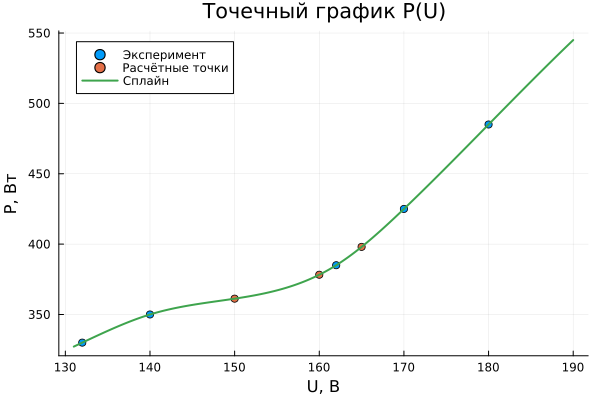

In [5]:
using Plots

# Функция вычисления коэффициентов сплайна b, c, d
function koef_spline(x, y)
    n = length(x)
    h = zeros(n)
    l = zeros(n)
    delt = zeros(n)
    lyam = zeros(n)
    b = zeros(n)
    c = zeros(n)
    d = zeros(n)
    
    # Вычисление элементов массива h
    for k in 2:n
        h[k] = x[k] - x[k-1]
    end
    
    # Вычисление элементов массива l
    for k in 2:n
        l[k] = (y[k] - y[k-1]) / h[k]
    end
    
    # Вычисление прогоночных коэффициентов
    delt[2] = -h[3] / (2 * (h[3] + h[2]))
    lyam[2] = 1.5 * (l[3] - l[2]) / (h[3] + h[2])
    
    for k in 4:n
        delt[k-1] = -h[k] / (2 * (h[k-1] + h[k]) + h[k-1] * delt[k-2])
        lyam[k-1] = (3 * (l[k] - l[k-1]) - h[k-1] * lyam[k-2]) / (2 * (h[k-1] + h[k]) + h[k-1] * delt[k-2])
    end
    
    # Вычисление коэффициентов сплайна c
    c[n] = 0
    for k in n:-1:3
        c[k-1] = delt[k-1] * c[k] + lyam[k-1]
    end
    
    # Расчёт коэффициентов сплайна b, d
    for k in 2:n
        d[k] = (c[k] - c[k-1]) / (3 * h[k])
        b[k] = l[k] + (2 * c[k] * h[k] + h[k] * c[k-1]) / 3
    end
    
    return b, c, d
end

# Расчёт ожидаемого значения в точке t
function my_spline(x, y, t)
    b, c, d = koef_spline(x, y)
    n = length(x)
    a = y
    
    # Определяем номер интервала j, в котором находится точка t
    if t > x[n-1]
        j = n
    else
        for i in 2:n
            if t<=x[i]
                j=i
                break
            end
        end
    end
    
    # Вычисление ожидаемого значения в точке t
    z = a[j] + b[j] * (t - x[j]) + c[j] * (t - x[j])^2 + d[j] * (t - x[j])^3
    return z
end

# Исходные данные, зависимость P(U)
U = [132, 140, 162, 170, 180]
P = [330, 350, 385, 425, 485]

# Точки, в которых требуется вычислить ожидаемое значение.
UP = [150, 160, 165]

# Вычисление ожидаемого значения.
PP = [my_spline(U, P, up) for up in UP]

# Формирование интерполяционной кривой на интервале [131;190]
U2 = 131:0.05:190
P2 = [my_spline(U, P, u) for u in U2]
println("Значения P(U) в точках UP:")
for (up, pp) in zip(UP, PP)
    println("P($up) ≈ $pp Вт")
end
plot(U, P, seriestype=:scatter, label="Эксперимент", 
    xlabel="U, В", 
    ylabel="P, Вт", 
    title="Точечный график P(U)",
    legend=:topleft
)
scatter!(UP, PP, label="Расчётные точки")
plot!(U2, P2, label="Сплайн", linewidth=2)

